# Motor Vehicle collisions

* link to dataset: https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95/data_preview

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("datasets/Motor_Vehicle_Collisions_-_Crashes_20260407.csv", delimiter=",")

/var/folders/tb/jb06w8hn5r72136sx1ztbxnr0000gn/T/ipykernel_14167/3959663291.py:1: DtypeWarning: Columns (0: ZIP CODE) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("datasets/Motor_Vehicle_Collisions_-_Crashes_20260407.csv", delimiter=",")


In [4]:
# verify lfs is working by printing the first few rows of the dataset
data.head(1)

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,09/11/2021,2:39,NaN,NaN,NaN,NaN,NaN,WHITESTONE EXPRESSWAY,20 AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4455765,Sedan,Sedan,NaN,NaN,NaN


## Preview

In [5]:
#The size of the dataset in MB
print(f"Size of the dataset: {data.memory_usage(deep=True).sum() / (1024 * 1024):.2f} MB")

Size of the dataset: 2075.61 MB


In [6]:
data.columns

Index(['CRASH DATE', 'CRASH TIME', 'BOROUGH', 'ZIP CODE', 'LATITUDE',
       'LONGITUDE', 'LOCATION', 'ON STREET NAME', 'CROSS STREET NAME',
       'OFF STREET NAME', 'NUMBER OF PERSONS INJURED',
       'NUMBER OF PERSONS KILLED', 'NUMBER OF PEDESTRIANS INJURED',
       'NUMBER OF PEDESTRIANS KILLED', 'NUMBER OF CYCLIST INJURED',
       'NUMBER OF CYCLIST KILLED', 'NUMBER OF MOTORIST INJURED',
       'NUMBER OF MOTORIST KILLED', 'CONTRIBUTING FACTOR VEHICLE 1',
       'CONTRIBUTING FACTOR VEHICLE 2', 'CONTRIBUTING FACTOR VEHICLE 3',
       'CONTRIBUTING FACTOR VEHICLE 4', 'CONTRIBUTING FACTOR VEHICLE 5',
       'COLLISION_ID', 'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2',
       'VEHICLE TYPE CODE 3', 'VEHICLE TYPE CODE 4', 'VEHICLE TYPE CODE 5'],
      dtype='str')

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2253192 entries, 0 to 2253191
Data columns (total 29 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   CRASH DATE                     str    
 1   CRASH TIME                     str    
 2   BOROUGH                        str    
 3   ZIP CODE                       object 
 4   LATITUDE                       float64
 5   LONGITUDE                      float64
 6   LOCATION                       str    
 7   ON STREET NAME                 str    
 8   CROSS STREET NAME              str    
 9   OFF STREET NAME                str    
 10  NUMBER OF PERSONS INJURED      float64
 11  NUMBER OF PERSONS KILLED       float64
 12  NUMBER OF PEDESTRIANS INJURED  int64  
 13  NUMBER OF PEDESTRIANS KILLED   int64  
 14  NUMBER OF CYCLIST INJURED      int64  
 15  NUMBER OF CYCLIST KILLED       int64  
 16  NUMBER OF MOTORIST INJURED     int64  
 17  NUMBER OF MOTORIST KILLED      int64  
 18  CONTRIBUTING 

In [8]:
# print the range of dates in the dataset
print(data["CRASH DATE"].min())
print(data["CRASH DATE"].max())

01/01/2013
12/31/2025


In [9]:
# checking one example for each column
for col in data.columns:
    for i in range(len(data)):
        if pd.notna(data[col].iloc[i]):
            ddaa_example = data[col].iloc[i]
            break
    print(f"{col}: {ddaa_example}")

CRASH DATE: 09/11/2021
CRASH TIME: 2:39
BOROUGH: BROOKLYN
ZIP CODE: 11230.0
LATITUDE: 40.62179
LONGITUDE: -73.970024
LOCATION:     (40.62179, -73.970024)
ON STREET NAME: WHITESTONE EXPRESSWAY
CROSS STREET NAME: 20 AVENUE
OFF STREET NAME: 61        Ed Koch queensborough bridge
NUMBER OF PERSONS INJURED: 2.0
NUMBER OF PERSONS KILLED: 0.0
NUMBER OF PEDESTRIANS INJURED: 0
NUMBER OF PEDESTRIANS KILLED: 0
NUMBER OF CYCLIST INJURED: 0
NUMBER OF CYCLIST KILLED: 0
NUMBER OF MOTORIST INJURED: 2
NUMBER OF MOTORIST KILLED: 0
CONTRIBUTING FACTOR VEHICLE 1: Aggressive Driving/Road Rage
CONTRIBUTING FACTOR VEHICLE 2: Unspecified
CONTRIBUTING FACTOR VEHICLE 3: Unspecified
CONTRIBUTING FACTOR VEHICLE 4: Unspecified
CONTRIBUTING FACTOR VEHICLE 5: Unspecified
COLLISION_ID: 4455765
VEHICLE TYPE CODE 1: Sedan
VEHICLE TYPE CODE 2: Sedan
VEHICLE TYPE CODE 3: Sedan
VEHICLE TYPE CODE 4: Station Wagon/Sport Utility Vehicle
VEHICLE TYPE CODE 5: Station Wagon/Sport Utility Vehicle


In [10]:
# Combine the unique values from all three columns into one set
unique_factors = set(data["CONTRIBUTING FACTOR VEHICLE 1"]) | \
                 set(data["CONTRIBUTING FACTOR VEHICLE 2"]) | \
                 set(data["CONTRIBUTING FACTOR VEHICLE 3"])

print(f'Number of unique contributing factors: {len(unique_factors)}')
print(f'Unique contributing factors: {unique_factors}')

Number of unique contributing factors: 62
Unique contributing factors: {'Glare', 'Failure to Yield Right-of-Way', 'Texting', 'Fatigued/Drowsy', 'Backing Unsafely', '80', 'Outside Car Distraction', 'Pavement Defective', 'Tow Hitch Defective', 'Windshield Inadequate', 'Eating or Drinking', 'Driver Inattention/Distraction', 'Other Lighting Defects', 'Drugs (illegal)', 'Illness', '1', 'Oversized Vehicle', 'Aggressive Driving/Road Rage', 'Drugs (Illegal)', 'Cell Phone (hands-free)', 'Traffic Control Device Improper/Non-Working', 'Turning Improperly', 'Fell Asleep', 'Unsafe Speed', 'View Obstructed/Limited', 'Animals Action', 'Illnes', 'Traffic Control Disregarded', 'Lane Marking Improper/Inadequate', 'Passing Too Closely', 'Reaction to Uninvolved Vehicle', 'Alcohol Involvement', 'Following Too Closely', 'Pavement Slippery', 'Unspecified', 'Failure to Keep Right', 'Other Electronic Device', 'Steering Failure', 'Headlights Defective', 'Using On Board Navigation Device', 'Passing or Lane Usage

In [11]:
# removing all rows with missing values in Borough CODE column
print(f"Number of rows before removing missing Borough CODE: {len(data)}")
data_borough = data['BOROUGH'].copy()
data_borough = data_borough.dropna()
print(f"Number of rows after removing missing Borough CODE: {len(data_borough)}")

Number of rows before removing missing Borough CODE: 2253192
Number of rows after removing missing Borough CODE: 1565730


In [12]:
# removing all rows with missing values in ZIP CODE column
print(f"Number of rows before removing missing ZIP CODE: {len(data)}")
data_zip = data['ZIP CODE'].copy()
data_zip = data_zip.dropna()
print(f"Number of rows after removing missing ZIP CODE: {len(data_zip)}")

Number of rows before removing missing ZIP CODE: 2253192
Number of rows after removing missing ZIP CODE: 1565447


## Data preprocessing

In [37]:
df_clean = data.copy()

In [38]:
df_clean.isna().sum()

CRASH DATE                             0
CRASH TIME                             0
BOROUGH                           687462
ZIP CODE                          687787
LATITUDE                          240676
LONGITUDE                         240676
LOCATION                          240676
ON STREET NAME                    494034
CROSS STREET NAME                 862706
OFF STREET NAME                  1851532
NUMBER OF PERSONS INJURED             18
NUMBER OF PERSONS KILLED              31
NUMBER OF PEDESTRIANS INJURED          0
NUMBER OF PEDESTRIANS KILLED           0
NUMBER OF CYCLIST INJURED              0
NUMBER OF CYCLIST KILLED               0
NUMBER OF MOTORIST INJURED             0
NUMBER OF MOTORIST KILLED              0
CONTRIBUTING FACTOR VEHICLE 1       8152
CONTRIBUTING FACTOR VEHICLE 2     365477
CONTRIBUTING FACTOR VEHICLE 3    2090099
CONTRIBUTING FACTOR VEHICLE 4    2215899
CONTRIBUTING FACTOR VEHICLE 5    2242979
COLLISION_ID                           0
VEHICLE TYPE COD

#### Dropping nan values

As we will be working with geographical features of the data, we need to have consistency across columns such as borough, zip code, and coordinates - rows with NaNs will be dropped. 

For the features describing the collisions, we are not dropping NaN values,as it is expected that some refering to several vehicles will be empty, if it was a one-vehicle accident.

We will also drop the rows with nan values in number of persons injured and killed, as these features should be fully usable.

As the number of missing values in the columns containing street info would significantly further reduce the size of the dataset, while it is not sure if these features will be used, we decide to drop these features.

In [40]:
df_clean = df_clean.dropna(subset=['ZIP CODE', 'LATITUDE', 'LONGITUDE', 'BOROUGH', 'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED'])

In [41]:
df_clean = df_clean.drop(['ON STREET NAME', 'CROSS STREET NAME', 'OFF STREET NAME'], axis=1)
df_clean.head()

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
2,11/01/2023,1:29,BROOKLYN,11230,40.621790,-73.970024,"(40.62179, -73.970024)",1.0,0.0,0,...,Unspecified,Unspecified,NaN,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN
9,09/11/2021,9:35,BROOKLYN,11208,40.667202,-73.866500,"(40.667202, -73.8665)",0.0,0.0,0,...,NaN,NaN,NaN,NaN,4456314,Sedan,NaN,NaN,NaN,NaN
10,12/14/2021,8:13,BROOKLYN,11233,40.683304,-73.917274,"(40.683304, -73.917274)",0.0,0.0,0,...,NaN,NaN,NaN,NaN,4486609,NaN,NaN,NaN,NaN,NaN
13,12/14/2021,8:17,BRONX,10475,40.868160,-73.831480,"(40.86816, -73.83148)",2.0,0.0,0,...,Unspecified,NaN,NaN,NaN,4486660,Sedan,Sedan,NaN,NaN,NaN
14,12/14/2021,21:10,BROOKLYN,11207,40.671720,-73.897100,"(40.67172, -73.8971)",0.0,0.0,0,...,Unspecified,NaN,NaN,NaN,4487074,Sedan,NaN,NaN,NaN,NaN


In [ ]:
# for convenience we will convert the date and time columns to datetime format
df_clean['CRASH DATE'] = pd.to_datetime(df_clean['CRASH DATE']).dt.date
df_clean['CRASH TIME'] = pd.to_datetime(df_clean['CRASH TIME']).dt.time
df_clean

/var/folders/tb/jb06w8hn5r72136sx1ztbxnr0000gn/T/ipykernel_14167/79236691.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['CRASH TIME'] = pd.to_datetime(df_clean['CRASH TIME']).dt.time


,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
2,2023-11-01,01:29:00,BROOKLYN,11230,40.621790,-73.970024,"(40.62179, -73.970024)",1.0,0.0,0,...,Unspecified,Unspecified,NaN,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN
9,2021-09-11,09:35:00,BROOKLYN,11208,40.667202,-73.866500,"(40.667202, -73.8665)",0.0,0.0,0,...,NaN,NaN,NaN,NaN,4456314,Sedan,NaN,NaN,NaN,NaN
10,2021-12-14,08:13:00,BROOKLYN,11233,40.683304,-73.917274,"(40.683304, -73.917274)",0.0,0.0,0,...,NaN,NaN,NaN,NaN,4486609,NaN,NaN,NaN,NaN,NaN
13,2021-12-14,08:17:00,BRONX,10475,40.868160,-73.831480,"(40.86816, -73.83148)",2.0,0.0,0,...,Unspecified,NaN,NaN,NaN,4486660,Sedan,Sedan,NaN,NaN,NaN
14,2021-12-14,21:10:00,BROOKLYN,11207,40.671720,-73.897100,"(40.67172, -73.8971)",0.0,0.0,0,...,Unspecified,NaN,NaN,NaN,4487074,Sedan,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2253183,2021-04-20,13:01:00,MANHATTAN,10024,40.782463,-73.978830,"(40.782463, -73.97883)",1.0,0.0,0,...,Unspecified,NaN,NaN,NaN,4409287,Taxi,Bike,NaN,NaN,NaN
2253184,2021-04-14,21:51:00,BRONX,10457,40.846530,-73.891300,"(40.84653, -73.8913)",0.0,0.0,0,...,Unspecified,NaN,NaN,NaN,4409502,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
2253189,2021-04-20,17:00:00,BRONX,10458,40.855600,-73.885150,"(40.8556, -73.88515)",0.0,0.0,0,...,Unspecified,NaN,NaN,NaN,4409125,Sedan,NaN,NaN,NaN,NaN
2253190,2021-04-20,16:45:00,BROOKLYN,11204,40.625828,-73.990950,"(40.625828, -73.99095)",0.0,0.0,0,...,NaN,NaN,NaN,NaN,4408955,Sedan,NaN,NaN,NaN,NaN


## Dataset preprocessing for temporal analyses

In [48]:
df_time = df_clean.copy()

In [106]:
# create columns with the year, month, day, day of the week, and hour of a crash
df_time['YEAR'] = pd.to_datetime(df_time['CRASH DATE']).dt.year
df_time['MONTH'] = pd.to_datetime(df_time['CRASH DATE']).dt.month
df_time['DAY'] = pd.to_datetime(df_time['CRASH DATE']).dt.day
df_time['WEEKDAY'] = pd.to_datetime(df_time['CRASH DATE']).dt.day_name()
df_time['HOUR'] = pd.to_datetime(df_time['CRASH TIME'], format='%H:%M:%S').dt.hour
df_time.head()

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,...,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5,YEAR,MONTH,DAY,WEEKDAY,HOUR
2,2023-11-01,01:29:00,BROOKLYN,11230,40.621790,-73.970024,"(40.62179, -73.970024)",1.0,0.0,0,...,Moped,Sedan,Sedan,NaN,NaN,2023,11,1,Wednesday,1
9,2021-09-11,09:35:00,BROOKLYN,11208,40.667202,-73.866500,"(40.667202, -73.8665)",0.0,0.0,0,...,Sedan,NaN,NaN,NaN,NaN,2021,9,11,Saturday,9
10,2021-12-14,08:13:00,BROOKLYN,11233,40.683304,-73.917274,"(40.683304, -73.917274)",0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,2021,12,14,Tuesday,8
13,2021-12-14,08:17:00,BRONX,10475,40.868160,-73.831480,"(40.86816, -73.83148)",2.0,0.0,0,...,Sedan,Sedan,NaN,NaN,NaN,2021,12,14,Tuesday,8
14,2021-12-14,21:10:00,BROOKLYN,11207,40.671720,-73.897100,"(40.67172, -73.8971)",0.0,0.0,0,...,Sedan,NaN,NaN,NaN,NaN,2021,12,14,Tuesday,21


## How the number of collisions changes throughout the years?

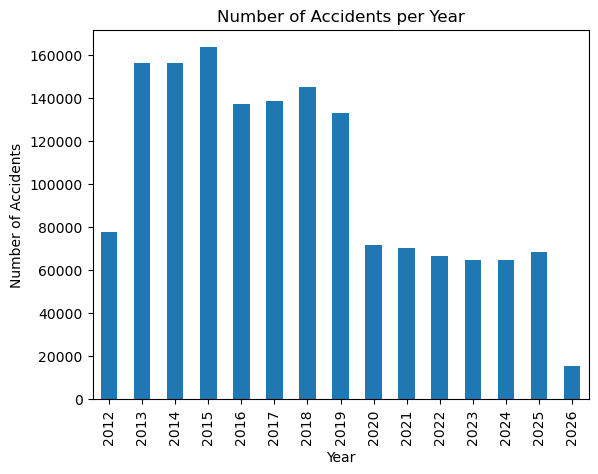

In [54]:
year_counts = df_time["YEAR"].value_counts().sort_index()
year_counts.plot(kind="bar", title="Number of Accidents per Year", xlabel="Year", ylabel="Number of Accidents")
plt.show()

In [56]:
df_time['CRASH DATE'].min()

datetime.date(2012, 7, 1)

Visible change in 2020, probably due to pandemic and therefore reduced traffic. Interestingly, the number of collisions did not pick up again after the pandemic. 

The number for 2012 is not representative, as we have data only from 1st of July 2012.

## What month has the most accidents?

<Axes: title={'center': 'Number of Accidents per Month'}, xlabel='Month', ylabel='Number of Accidents'>

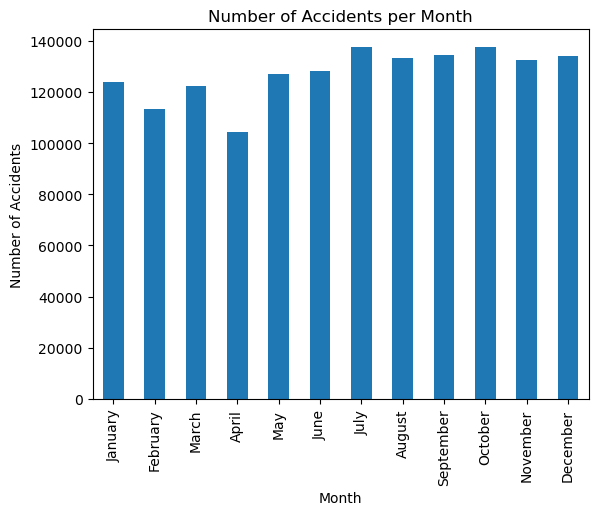

In [53]:
# What month has the most accidents? We use the column "CRASH DATE" to extract the month and count the number of accidents for each month, create a bar plot comparing each month
month_counts = df_time["MONTH"].value_counts().sort_index()
# map each month to their name
month_counts.index = month_counts.index.map({1: "January", 2: "February", 3: "March", 4: "April", 5: "May", 6: "June", 7: "July", 8: "August", 9: "September", 10: "October", 11: "November", 12: "December"})
month_counts.plot(kind="bar", title="Number of Accidents per Month", xlabel="Month", ylabel="Number of Accidents")


## When in a month do collisions happen?

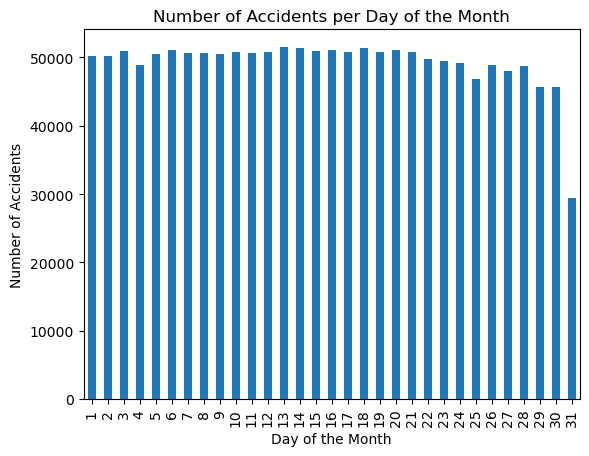

In [59]:
day_counts = df_time["DAY"].value_counts().sort_index()
day_counts.plot(kind="bar", title="Number of Accidents per Day of the Month", xlabel="Day of the Month", ylabel="Number of Accidents")
plt.show()

Nothing stands out, as data for 31st day of a month is recorded for half of the months.

## When in a week do the collisions happen?

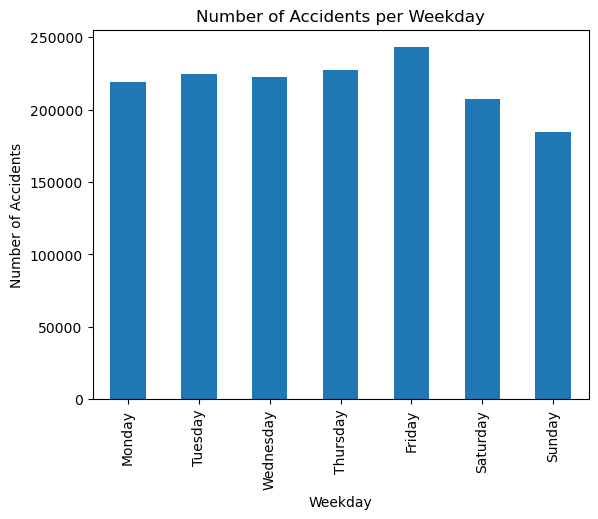

In [57]:
weekday_counts = df_time["WEEKDAY"].value_counts().reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
weekday_counts.plot(kind="bar", title="Number of Accidents per Weekday", xlabel="Weekday", ylabel="Number of Accidents")
plt.show()

## Did the weekly distribution change after pandemic?

We will consider the period from 2012 to 2019 as "before pandemic" and the period from 2020 to 2024 as "after pandemic". We will create two separate dataframes for these periods and then plot the weekly distribution of accidents for each period.

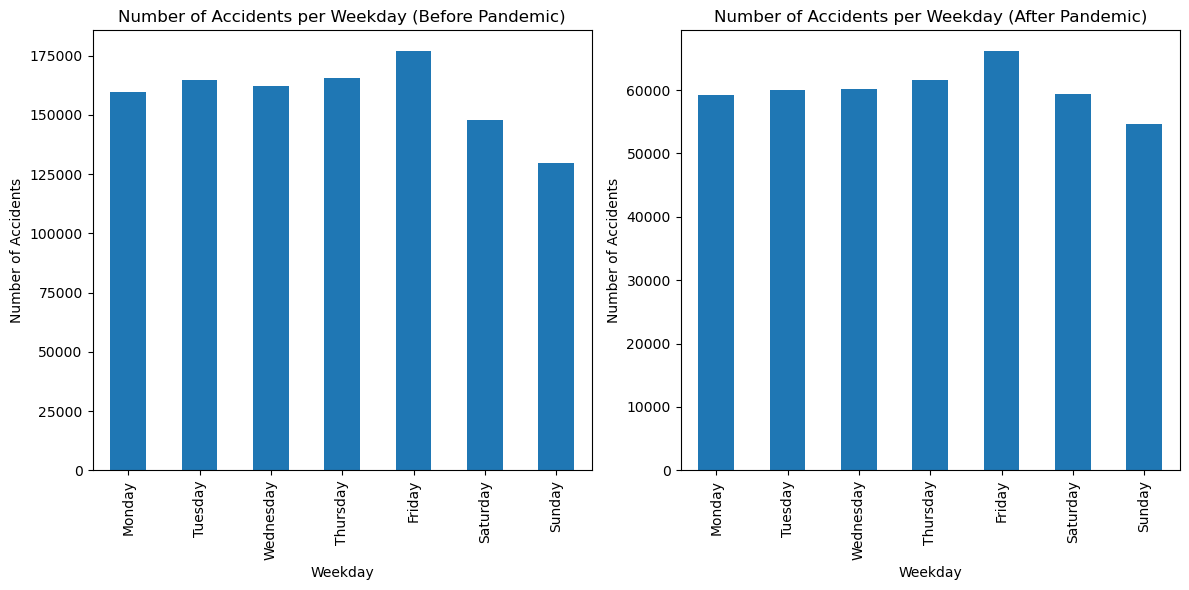

In [92]:
df_before_pandemic = df_time[df_time['YEAR'] < 2020]
df_after_pandemic = df_time[df_time['YEAR'] >= 2020]
weekday_counts_before = df_before_pandemic["WEEKDAY"].value_counts().reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
weekday_counts_after = df_after_pandemic["WEEKDAY"].value_counts().reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
weekday_counts_before.plot(kind="bar", title="Number of Accidents per Weekday (Before Pandemic)", xlabel="Weekday", ylabel="Number of Accidents")
plt.subplot(1, 2, 2)
weekday_counts_after.plot(kind="bar", title="Number of Accidents per Weekday (After Pandemic)", xlabel="Weekday", ylabel="Number of Accidents")
plt.tight_layout()
plt.show()

## What time of day does crashes occur the most ? 

<Axes: title={'center': 'Number of Accidents per Hour'}, xlabel='Hour of Day', ylabel='Number of Accidents'>

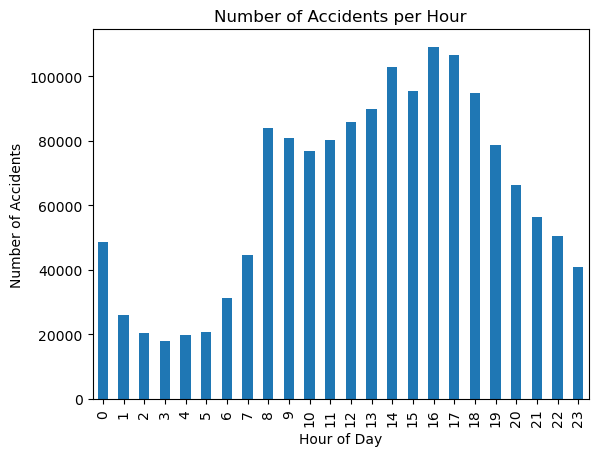

In [52]:
# What time of day has the most accidents? We use the column "CRASH TIME" to extract the hour and count the number of accidents for each hour, create a bar plot comparing each hour
hour_counts = df_time["HOUR"].value_counts().sort_index()
hour_counts.plot(kind="bar", title="Number of Accidents per Hour", xlabel="Hour of Day", ylabel="Number of Accidents")

Most collisions happen during the day, when the traffic is dense. 

## Did hourly distribution change after pandemic?

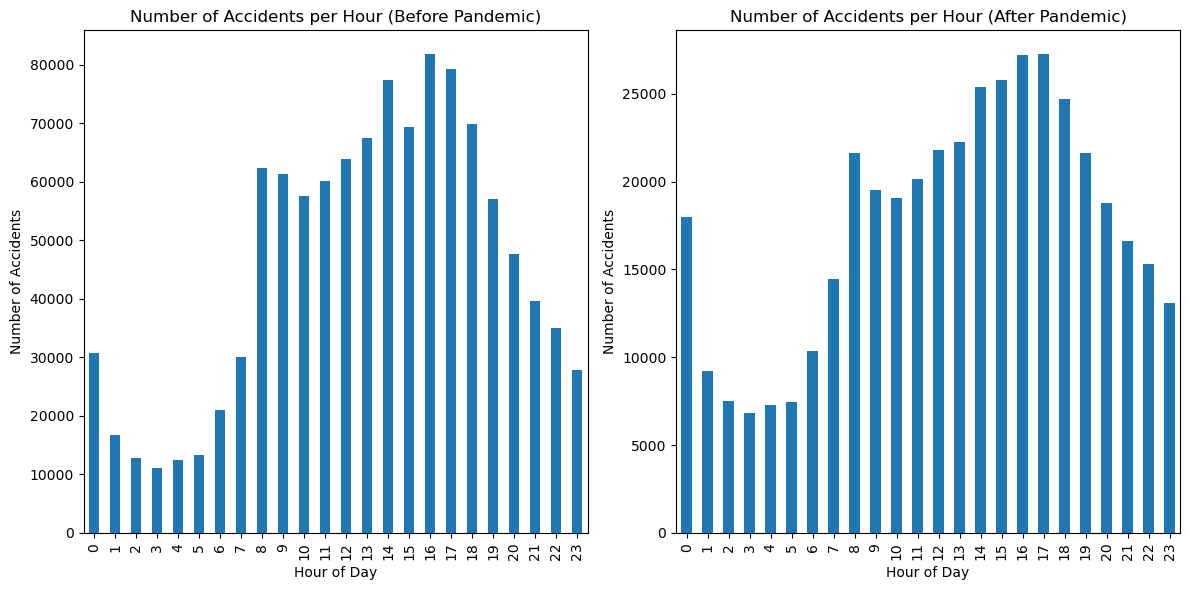

In [ ]:
hour_counts_before = df_before_pandemic["HOUR"].value_counts().sort_index()
hour_counts_after = df_after_pandemic["HOUR"].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
hour_counts_before.plot(kind="bar", title="Number of Accidents per Hour (Before Pandemic)", xlabel="Hour of Day", ylabel="Number of Accidents")
plt.subplot(1, 2, 2)
hour_counts_after.plot(kind="bar", title="Number of Accidents per Hour (After Pandemic)", xlabel="Hour of Day", ylabel="Number of Accidents")
plt.tight_layout()
plt.show()

## Did the number of serious accidents also drop after pandemic?

In [64]:
df_clean['NUMBER OF PERSONS INJURED'].nunique()

29

In [65]:
df_clean['NUMBER OF PERSONS KILLED'].nunique()

7

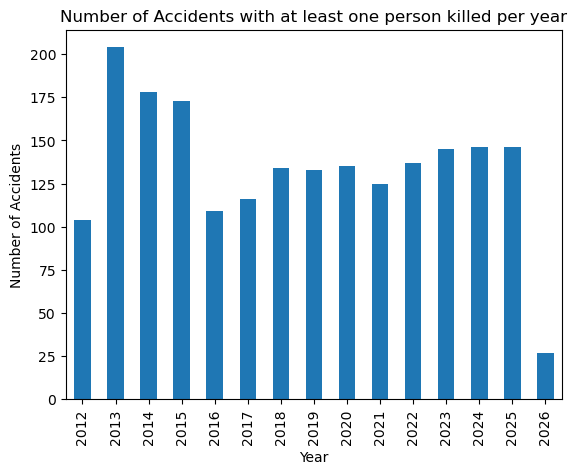

In [74]:
df_killed = df_time[df_time['NUMBER OF PERSONS KILLED'] > 0]
killed_year_counts = df_killed['YEAR'].value_counts().sort_index()
killed_year_counts.plot(kind="bar", title="Number of Accidents with at least one person killed per year", xlabel="Year", ylabel="Number of Accidents")
plt.show()

## When in a day do the more serious accidents happen?

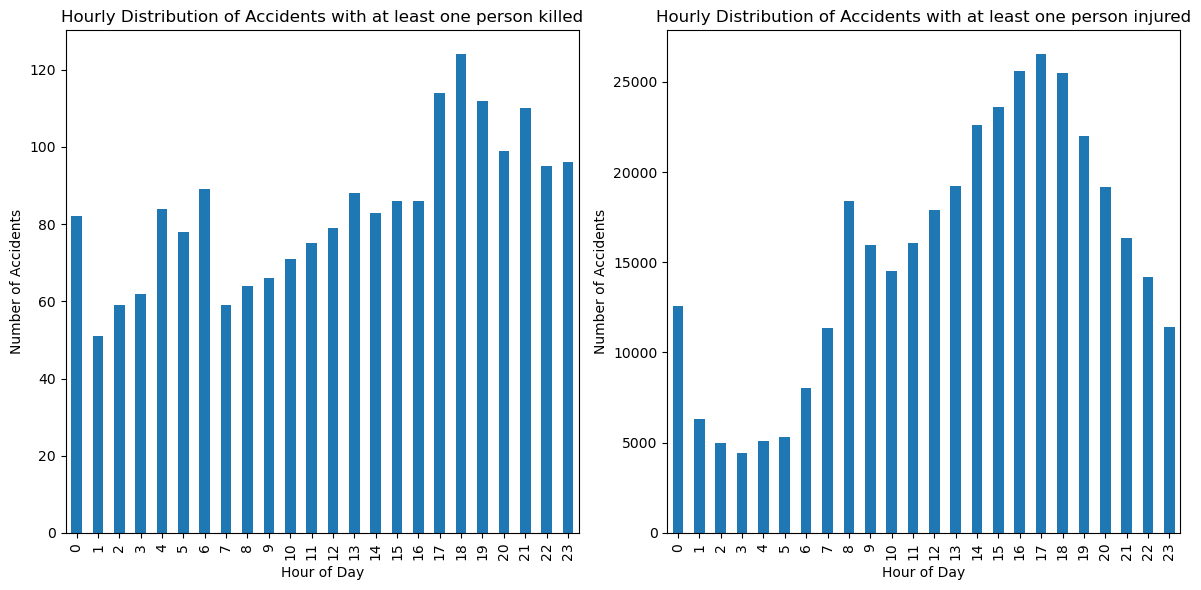

In [104]:
# plot hourly distribution of accidents with at least one person killed, hourly distribution of accidents with at least one person injured, and hourly distribution of all accidents
hourly_killed_counts = df_killed["HOUR"].value_counts().sort_index()
hourly_injured_counts = df_time[df_time['NUMBER OF PERSONS INJURED'] > 0]["HOUR"].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
hourly_killed_counts.plot(kind='bar', title="Hourly Distribution of Accidents with at least one person killed", xlabel="Hour of Day", ylabel="Number of Accidents")
plt.subplot(1, 2, 2)
hourly_injured_counts.plot(kind='bar', title="Hourly Distribution of Accidents with at least one person injured", xlabel="Hour of Day", ylabel="Number of Accidents")
plt.tight_layout()
plt.show()

## What are the most common contributing factors?

We combine contributing factors for all vehicles, leave out Unspecified and plot the values on a log scale axis for better visualization.

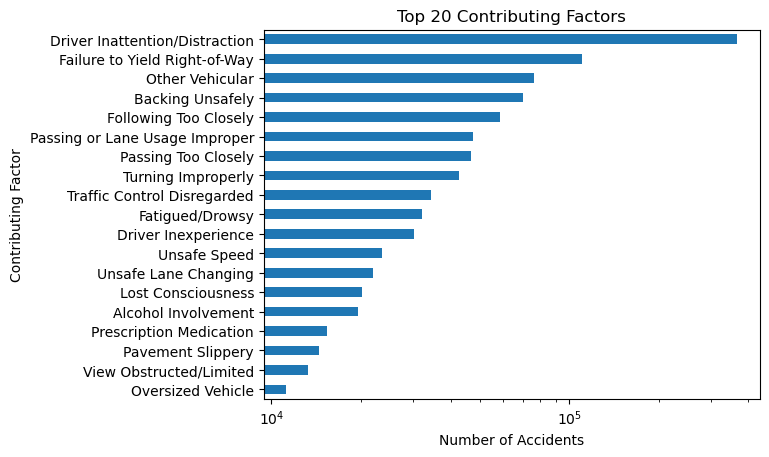

In [90]:
contributing_factors = pd.concat([df_time['CONTRIBUTING FACTOR VEHICLE 1'], df_time['CONTRIBUTING FACTOR VEHICLE 2'], df_time['CONTRIBUTING FACTOR VEHICLE 3'], df_time['CONTRIBUTING FACTOR VEHICLE 4'], df_time['CONTRIBUTING FACTOR VEHICLE 5']])
factor_counts = contributing_factors.value_counts().head(20).drop("Unspecified")
factor_counts.plot(kind="barh", title="Top 20 Contributing Factors", xlabel="Number of Accidents", ylabel="Contributing Factor", logx=True)
plt.gca().invert_yaxis()
plt.show()

## Did the contributing factors change after pandemic?

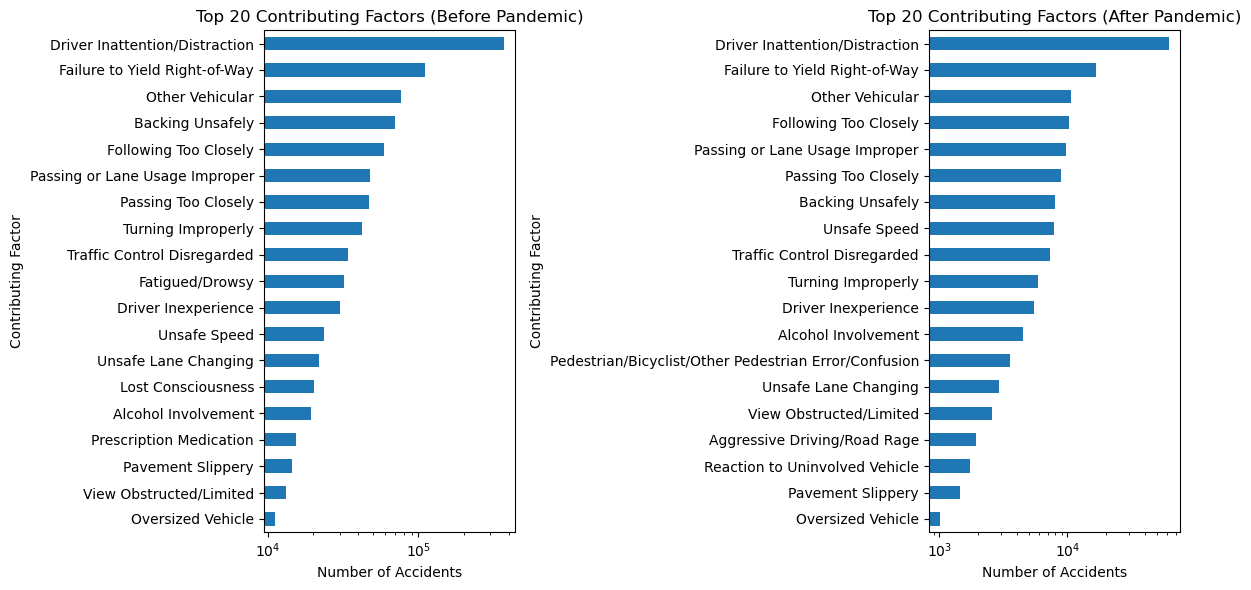

In [91]:
contributing_factors_before = pd.concat([df_time['CONTRIBUTING FACTOR VEHICLE 1'], df_time['CONTRIBUTING FACTOR VEHICLE 2'], df_time['CONTRIBUTING FACTOR VEHICLE 3'], df_time['CONTRIBUTING FACTOR VEHICLE 4'], df_time['CONTRIBUTING FACTOR VEHICLE 5']])
contributing_factors_after = pd.concat([df_after_pandemic['CONTRIBUTING FACTOR VEHICLE 1'], df_after_pandemic['CONTRIBUTING FACTOR VEHICLE 2'], df_after_pandemic['CONTRIBUTING FACTOR VEHICLE 3'], df_after_pandemic['CONTRIBUTING FACTOR VEHICLE 4'], df_after_pandemic['CONTRIBUTING FACTOR VEHICLE 5']])
factor_counts_before = contributing_factors_before.value_counts().head(20).drop("Unspecified")
factor_counts_after = contributing_factors_after.value_counts().head(20).drop("Unspecified")

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
factor_counts_before.plot(kind="barh", title="Top 20 Contributing Factors (Before Pandemic)", xlabel="Number of Accidents", ylabel="Contributing Factor", logx=True)
plt.gca().invert_yaxis()
plt.subplot(1, 2, 2)
factor_counts_after.plot(kind="barh", title="Top 20 Contributing Factors (After Pandemic)", xlabel="Number of Accidents", ylabel="Contributing Factor", logx=True)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Do some zipcodes have more crashes ? 

In [ ]:
# Iterate over all values in zipcode columns and identify their types, only print unique types
unique_zipcode_types = data["ZIP CODE"].apply(type).unique()
print(unique_zipcode_types)

[<class 'float'> <class 'str'>]


<Axes: title={'center': 'Number of Accidents per Zipcode'}, xlabel='Zipcode', ylabel='Number of Accidents'>

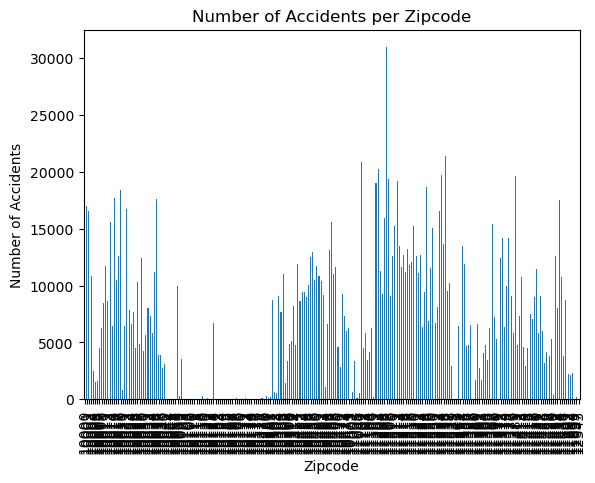

In [13]:
# What zipcode has the most accidents? We use the column "ZIP CODE" to count the number of accidents for each zipcode, create a bar plot comparing each zipcode
data["ZIP CODE"] = (
    data["ZIP CODE"]
    .astype(str)                           # convert everything to string first
    .str.strip()                           # remove whitespace
    .replace("", float("nan"))             # turn empty strings into NaN
    .dropna()                              # drop NaNs
    .astype(float)                         # normalize "10001.0" strings
    .astype(int)                           # drop the decimal
    .astype(str)                           # convert to string
    .str.zfill(5)                          # restore leading zeros
)
zipcode_counts = data["ZIP CODE"].dropna().value_counts().sort_index()
zipcode_counts.plot(kind="bar", title="Number of Accidents per Zipcode", xlabel="Zipcode", ylabel="Number of Accidents")


## Did vision zero mitigate crashes and/or fatalities? 

## When are crashes most deadly vs. most frequent?

## Which cross sections are most deadly ??

## Are some car owners more deadly than others ? Does it that say more about the car or the person ? 

## When does the most violent crashes occur (meaning more people die or not only injured) ?